# DSC 530 Term Project
* Mallory Young

## Exploring the Data
* Importing code and packages needed for this project
* Importing and displaying the data frame
* Checking for missing values
* Creating a caseid column and re-ordering the columns

In [1]:
#code that allows me to connect to the Thinkstats2 folder and utilize the thinkstats2 and thinkplot 
#pre-made classes such as thinkplot.Hist and thinkstats2.pmf
from os.path import basename, exists

def download(url):
    filename = basename(url)
    if not exists(filename):
        from urllib.request import urlretrieve

        local, _ = urlretrieve(url, filename)
        print("Downloaded " + local)

download("https://github.com/AllenDowney/ThinkStats2/raw/master/code/thinkstats2.py")
download("https://github.com/AllenDowney/ThinkStats2/raw/master/code/thinkplot.py")

In [2]:
#Importing any packages I might need for these exercises
import numpy as np
import pandas as pd
import math
import thinkstats2
import thinkplot
import seaborn as sns
import matplotlib.pyplot as plt 

In [3]:
#Importing the data frame
dfStud = pd.read_csv('Students.csv')
#Display the first 10 rows of data
dfStud.head()

,caseid,Math,Reading,absences,Dalc,Walc,school,sex,age,address,...,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,health
0,1,50,53,6,1,1,GP,F,18,U,...,no,no,yes,yes,no,no,4,3,4,3
1,2,50,50,4,1,1,GP,F,17,U,...,no,no,no,yes,yes,no,5,3,3,3
2,3,57,60,10,2,3,GP,F,15,U,...,yes,no,yes,yes,yes,no,4,3,2,3
3,4,83,80,2,1,1,GP,F,15,U,...,yes,yes,yes,yes,yes,yes,3,2,2,5
4,5,53,67,4,1,2,GP,F,16,U,...,yes,no,yes,yes,no,no,4,3,2,5


In [4]:
#checking for missing values
dfStud.isna().sum()

caseid        0
Math          0
Reading       0
absences      0
Dalc          0
Walc          0
school        0
sex           0
age           0
address       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
famsize       0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
health        0
dtype: int64

In [5]:
#creating a "caseid" column to use as an identifier for referencing specific students
dfStud.loc[:, 'caseid'] = range(1, len(dfStud) + 1)
dfStud['caseid'] = dfStud['caseid'].astype(int)

In [6]:
#re-ordering the columns so I don't have to keep scrolling sideways to view the most relevant data. 
dfStud = dfStud[['caseid', 'Math', 'Reading', 'absences', 'Dalc', 'Walc', 'school', 'sex', 'age', 'address',  
       'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'famsize', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'health']]
dfStud.head()

,caseid,Math,Reading,absences,Dalc,Walc,school,sex,age,address,...,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,health
0,1,50,53,6,1,1,GP,F,18,U,...,no,no,yes,yes,no,no,4,3,4,3
1,2,50,50,4,1,1,GP,F,17,U,...,no,no,no,yes,yes,no,5,3,3,3
2,3,57,60,10,2,3,GP,F,15,U,...,yes,no,yes,yes,yes,no,4,3,2,3
3,4,83,80,2,1,1,GP,F,15,U,...,yes,yes,yes,yes,yes,yes,3,2,2,5
4,5,53,67,4,1,2,GP,F,16,U,...,yes,no,yes,yes,no,no,4,3,2,5


### Statistical Question
The 5 variables I will use during my analysis are: Dalc, Walc, absences, Math, and Reading. 

### Variable Descriptions
| Variable      | Type       | Description
| :---:         | :---:      | :---:  
| Dalc          | int 64     | School day alcohol consumption 
|               |            |  (from 1 - very low to 5 - very high)
| Walc          | int 64     | Weekend alcohol consumption 
|               |            |  (from 1 - very low to 5 - very high)
| absences      | int 64     | Number of school absences 
|               |            |  (from 0 to 93)
| Math          | int 64     | Math final grade
|               |            |  (from 0 to 100)
| Reading       | int 64     | Reading final grade
|               |            |  (from 0 to 100)

* Additionally, caseid (type: int32) was added to use as an identifier for referencing specific students.

## Histograms for the 5 Variables
* Dalc, Walc, absences, Math, Reading
* Descriptive statistics for each variable

In [7]:
#learning information about the numerical columns in the data frame to compare to the histograms below. 
dfStud.describe()

,caseid,Math,Reading,absences,Dalc,Walc,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,health
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,198.000000,69.703797,67.918987,5.708861,1.481013,2.291139,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,3.554430
std,114.170924,11.097439,16.463574,8.003096,0.890741,1.287897,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,1.390303
min,1.000000,40.000000,0.000000,0.000000,1.000000,1.000000,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,99.500000,60.000000,63.000000,0.000000,1.000000,1.000000,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,3.000000
50%,198.000000,70.000000,70.000000,4.000000,1.000000,2.000000,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,4.000000
75%,296.500000,77.000000,77.000000,8.000000,2.000000,3.000000,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,5.000000
max,395.000000,97.000000,97.000000,75.000000,5.000000,5.000000,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000


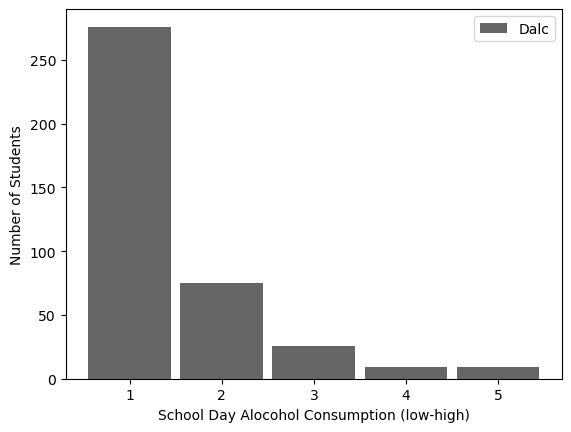

In [8]:
#Use Hist to plot the values and their frequencies as a bar graph.
hist = thinkstats2.Hist(dfStud.Dalc)
#Creates a label for the graph legend
thinkplot.Hist(hist, label='Dalc', color='black')
#Use Config to take the parameters to label the x and y axes
thinkplot.Config(xlabel='School Day Alocohol Consumption (low-high)', ylabel='Number of Students')

#### Desriptive Statistics for Dalc
* Spread: Asymmetric distribution; right skewed* 
Tails: Tail to extending to the right


In [9]:
#Descriptive statistics for the 'Dalc" (School Day Alcohol Comsumption) variable
dfStud['Dalc'].describe()

count    395.000000
mean       1.481013
std        0.890741
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max        5.000000
Name: Dalc, dtype: float64

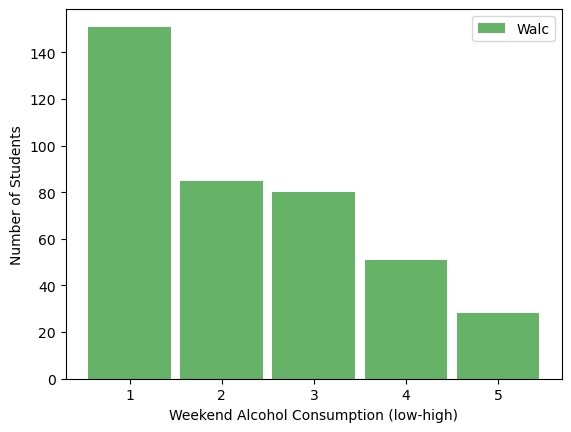

In [10]:
#Use Hist to plot the values and their frequencies as a bar graph.
hist = thinkstats2.Hist(dfStud.Walc)
#Creates a label for the graph legend
thinkplot.Hist(hist, label='Walc', color='green')
#Use Config to take the parameters to label the x and y axes
thinkplot.Config(xlabel='Weekend Alcohol Consumption (low-high)', ylabel='Number of Students')

#### Desriptive Statistics for Walc
* Spread: Asymmetric distribution; right skewed
* Tails: Tail extending to the right

In [11]:
#Descriptive statistics for the 'Walc" (Weekend Alcohol Comsumption) variable
dfStud['Walc'].describe()

count    395.000000
mean       2.291139
std        1.287897
min        1.000000
25%        1.000000
50%        2.000000
75%        3.000000
max        5.000000
Name: Walc, dtype: float64

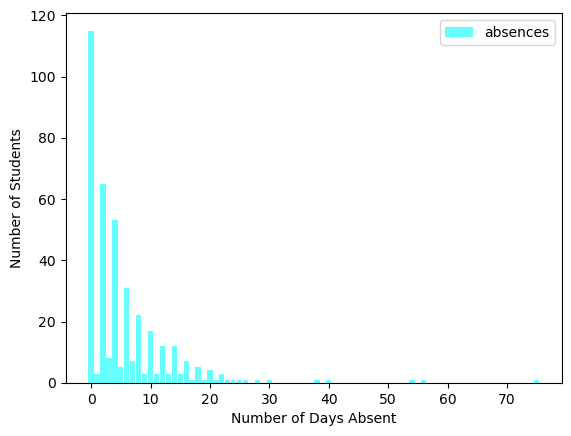

In [12]:
#Use Hist to plot the values and their frequencies as a bar graph.
hist = thinkstats2.Hist(dfStud.absences)
#Creates a label for the graph legend
thinkplot.Hist(hist, label='absences', color='cyan')
#Use Config to take the parameters to label the x and y axes
thinkplot.Config(xlabel='Number of Days Absent', ylabel='Number of Students')

#### Desriptive Statistics for absences
* Spread: Asymmetric distribution; right skewed
* Tails: Tail to extending far to the right (Identified outlier data)

In [13]:
#Descriptive statistics for the 'absences" variable
dfStud['absences'].describe()

count    395.000000
mean       5.708861
std        8.003096
min        0.000000
25%        0.000000
50%        4.000000
75%        8.000000
max       75.000000
Name: absences, dtype: float64

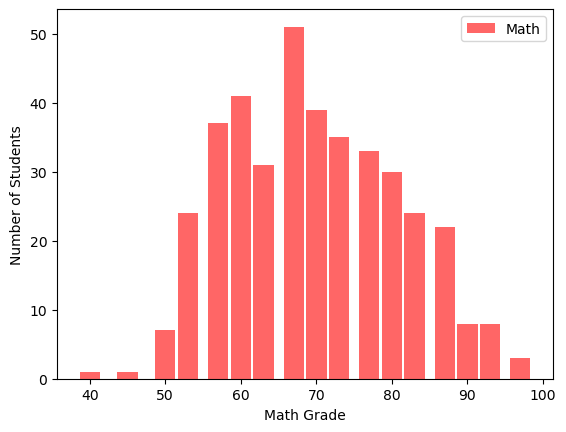

In [14]:
#Use Hist to plot the values and their frequencies as a bar graph.
hist = thinkstats2.Hist(dfStud.Math)
#Creates a label for the graph legend
thinkplot.Hist(hist, label='Math', color='red')
#Use Config to take the parameters to label the x and y axes
thinkplot.Config(xlabel='Math Grade', ylabel='Number of Students')

#### Desriptive Statistics for Math
* Spread: Normal distribution
* Tails: Tails on both sides

In [15]:
#Descriptive statistics for the 'Math" final grade variable
dfStud['Math'].describe()

count    395.000000
mean      69.703797
std       11.097439
min       40.000000
25%       60.000000
50%       70.000000
75%       77.000000
max       97.000000
Name: Math, dtype: float64

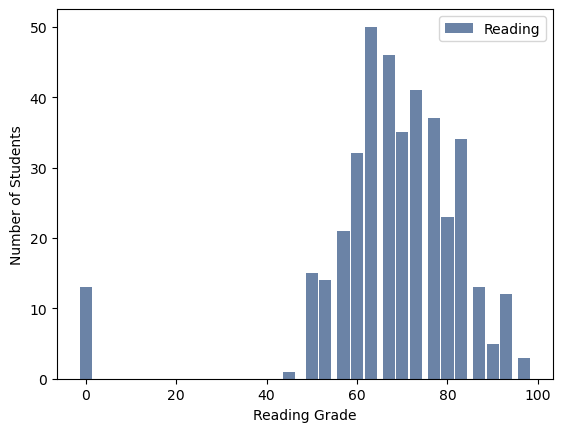

In [16]:
#Use Hist to plot the values and their frequencies as a bar graph.
hist = thinkstats2.Hist(dfStud.Reading)
#Creates a label for the graph legend
thinkplot.Hist(hist, label='Reading')
#Use Config to take the parameters to label the x and y axes
thinkplot.Config(xlabel='Reading Grade', ylabel='Number of Students')

#### Desriptive Statistics for Reading
* Spread: Normal distribution (when ignoring potential outlier data)
* Tails: Tails on both sides. Outlier peak of data to the left of the distribution


In [17]:
#Descriptive statistics for the 'Reading" final grade variable
dfStud['Reading'].describe()

count    395.000000
mean      67.918987
std       16.463574
min        0.000000
25%       63.000000
50%       70.000000
75%       77.000000
max       97.000000
Name: Reading, dtype: float64

## Identification and Handling of Outliers

**How do we identify outliers?**
* Observing data points on the histogram that are far away from the other data
* Taking a closer look at the outliers using a boxplot 
* Defining outliers mathematically with Interquartile Range (IQR)

**How do we handle outliers?**
* Ask questions about why the outliers exist: 
  * Are they valid and explainable? – Consider leaving them in the data set
  * Are they a result of an error in data collection? – Consider removing them from the data set

Based on the histograms of the 5 variables: **Reading** and **absences** were immediately identified as having possible outliers. 
We will start by analyzing the **Reading** data outliers by viewing the outliers in a boxplot, then calculating outliers mathematically using the interquartile range (IQR)


#### Analysis and Handling of Reading Data Outliers

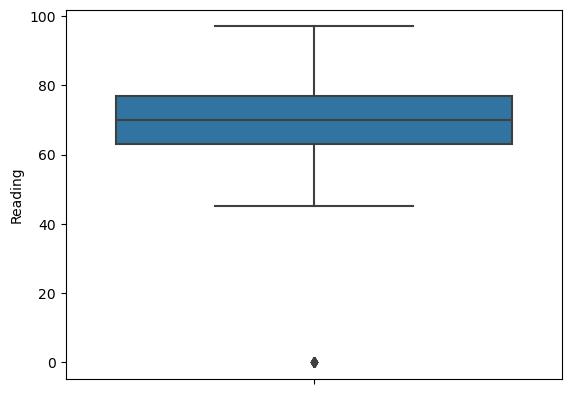

In [18]:
#creating a boxplot of the Reading data. Outlier data is shown as a diamond outside of the box.  
sns.boxplot(data=dfStud, y='Reading')
plt.show()

In [19]:
#Defining outliers mathematically using the Interquartile Range (IQR)
#Step 1: Finding the 75th & 25th percentiles for the Reading data
seventy_fifthR = dfStud['Reading'].quantile(0.75)
twenty_fifthR = dfStud['Reading'].quantile(0.25)
seventy_fifthR, twenty_fifthR

(77.0, 63.0)

In [20]:
#Step 2: Calculate the IQR for the Reading data
Reading_iqr = seventy_fifthR - twenty_fifthR
Reading_iqr

14.0

In [21]:
#Step 3: Find the upper & lower limit threshold values 
upperR = seventy_fifthR + (1.5 * Reading_iqr)
lowerR = twenty_fifthR - (1.5 * Reading_iqr)
upperR, lowerR

(98.0, 42.0)

In [22]:
#Subsetting and printing values outside of the upper limit
upper_R = dfStud[(dfStud['Reading'] > upperR)]
upper_R[['caseid', 'Math', 'Reading', 'absences']]

,caseid,Math,Reading,absences


**Results:** There are no identified Reading outlier values above the upper limit threshold. 

In [23]:
#Subsetting and printing values outside of the lower limit
#Subsetting and printing values outside of the upper limit
lower_R = dfStud[(dfStud['Reading'] < lowerR)]
lower_R[['caseid', 'Math', 'Reading', 'absences']]

,caseid,Math,Reading,absences
130,131,73,0,0
131,132,60,0,0
134,135,63,0,0
135,136,70,0,0
136,137,67,0,0
137,138,45,0,0
144,145,50,0,0
153,154,50,0,0
162,163,57,0,0
242,243,53,0,0


**Results:** 
* There are 13 identified Reading outlier values below the lower limit threshold. 
* Questions to ask about these outliers:
  * Why do these students have 0 grade in Reading, but not Math?
  * Is reading the first class of the day for these students and they are coming to school tardy?
  * Are these 0 grades an error in the grading system?
  * Was there a missing reading grade for these students, but instead of null, a 0 was entered in its place?
* As a former teacher, domain expertise about this type of data and how student grades work will help me deal with these outliers.
  * The odds of a student receiving a 0 grade are very small in a classroom situation. Most students will do at least some work, and earn a failing grade.
  * Earning a 0 grade comes from doing no work at all and/or never attending the class to begin with.
  * We can see that these students also have 0 absences, therefore we can conclude that these 0 grades must be an error.
* Handling these outliers:
  *  These errors in the data will skew the analysis of our statistical question, and therefore should be removed. 

In [24]:
#Removing the 13 rows of student outlier/error data for the Reading final grade variable
dfStud = dfStud.drop(dfStud[dfStud.Reading < lowerR].index)

In [25]:
#Displaying the NEW descriptive statistics for the 'Reading" final grade variable
dfStud['Reading'].describe()

count    382.000000
mean      70.230366
std       10.841706
min       45.000000
25%       63.000000
50%       70.000000
75%       77.000000
max       97.000000
Name: Reading, dtype: float64

#### Analysis and Handling of Absences Data Outliers

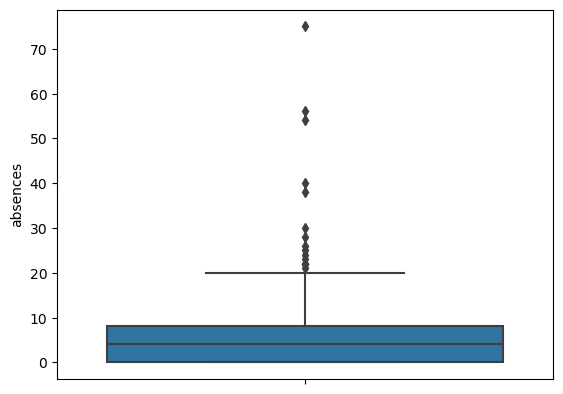

In [26]:
#creating a boxplot of the absences data. Outlier data is shown as a diamond outside of the box.  
sns.boxplot(data=dfStud, y='absences')
plt.show()

In [27]:
#Defining outliers mathematically using the Interquartile Range (IQR)
#Step 1: Finding the 75th & 25th percentiles for the absences data
seventy_fifthA = dfStud['absences'].quantile(0.75)
twenty_fifthA = dfStud['absences'].quantile(0.25)
seventy_fifthA, twenty_fifthA

(8.0, 0.0)

In [28]:
#Step 2: Calculate the IQR for the absences data
absences_iqr = seventy_fifthA - twenty_fifthA
absences_iqr

8.0

In [29]:
#Step 3: Find the upper & lower limit threshold values 
upperA = seventy_fifthA + (1.5 * absences_iqr)
lowerA = twenty_fifthA - (1.5 * absences_iqr)
upperA, lowerA

(20.0, -12.0)

In [30]:
#Subsetting and printing values outside of the lower limit
lower_A = dfStud[(dfStud['absences'] < lowerA)]
lower_A[['caseid', 'Math', 'Reading', 'absences']]

,caseid,Math,Reading,absences


**Results:** There are no identified absences outlier values above the upper limit threshold. 

In [31]:
#Subsetting and printing values outside of the upper limit
upper_A = dfStud[(dfStud['absences'] > upperA)]
upper_A[['caseid', 'Math', 'Reading', 'absences']]

,caseid,Math,Reading,absences
40,41,57,67,25
74,75,70,73,54
103,104,57,53,26
183,184,63,63,56
198,199,93,93,24
205,206,67,63,28
216,217,53,53,22
260,261,90,93,21
276,277,67,63,75
277,278,63,63,22


**Results:** 
* There are 15 identified absences outlier values above the upper limit threshold. 
* Questions to ask about these outliers:
  * There are 93 days recorded for this school year; Is it feasible that this many students could have as many as 50-75 absences during the school year?
  * Is it possible for the students with a high number of absences to still have passing Math & Reading grades?
* As a former teacher, domain expertise about this type of data and how student absences work will help me deal with these outliers.
  * The upper limit threshold for this data is 20 days; a feasible number of days for student absences. 
  * I had multiple students absent more than 10 days a quarter, which equals more than 40 days a year. 
  * Many of these students failed their classes due to missing work, however several students were able to maintain passing grades in their classes by keeping up with their classwork. 
  * Therefore, students having such high absences and maintaining C and D grades, is feasible. 
* Handling these outliers:
  *  Since these outliers are not viewed to be errors, then they can be left in the data set and used for the analysis of our statistical question. 

#### Examining the 3 Remaining Variables for Outliers
There were no noticable outliers for the Dalc, Walc, and Math variables based on their histograms. Let's see if we can identify any outliers with a boxplot for each variable...

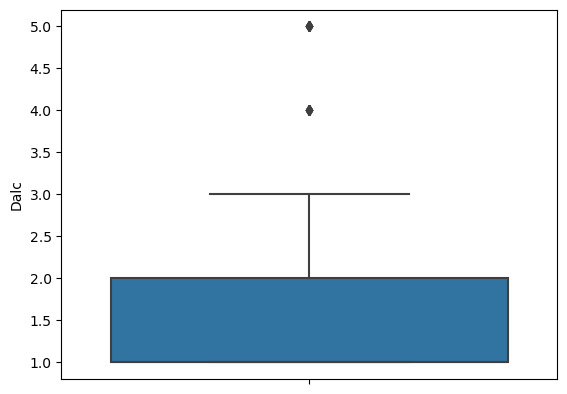

In [32]:
#creating a boxplot of the Dalc data. Outlier data is shown as a diamond outside of the box.  
sns.boxplot(data=dfStud, y='Dalc')
plt.show()

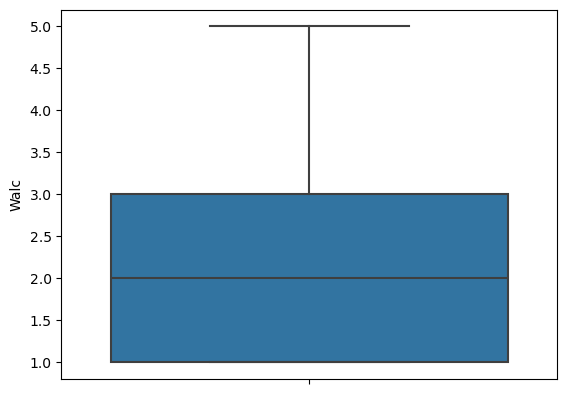

In [33]:
#creating a boxplot of the Walc data. Outlier data is shown as a diamond outside of the box.  
sns.boxplot(data=dfStud, y='Walc')
plt.show()

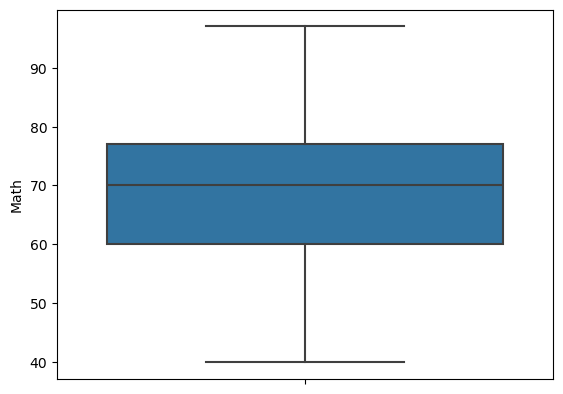

In [34]:
#creating a boxplot of the Math data. Outlier data is shown as a diamond outside of the box.  
sns.boxplot(data=dfStud, y='Math')
plt.show()

**Results:** 
* The only other boxplot showing potential outliers is the **Dalc** variable. This data measures a range from 1-5, the level of alcohol consuption for a student on week days during the school year. 
* The boxplot identifies students with an alcohol consumption levels 4 and 5 as outliers. 
* The table below filters all of the students with the outlier data for Dalc.
    * As we can see from the table, there are 18 students who have a 4 or higher Dalc, but these students also have higher Walc values as well.
    * Therefore, this data does appear to be accurate and should be left in the data set.  

In [35]:
dfStud.loc[dfStud['Dalc'] > 3]

,caseid,Math,Reading,absences,Dalc,Walc,school,sex,age,address,...,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,health
29,30,67,73,16,5,5,GP,M,16,U,...,yes,yes,yes,yes,yes,yes,4,4,5,5
54,55,67,77,6,4,4,GP,F,15,U,...,yes,no,yes,yes,yes,no,5,3,4,1
61,62,67,60,6,5,5,GP,F,16,U,...,no,yes,no,yes,yes,yes,5,5,5,5
66,67,77,77,4,5,5,GP,M,15,U,...,no,yes,no,yes,yes,yes,1,3,3,3
100,101,57,57,14,5,5,GP,M,16,U,...,yes,yes,yes,yes,yes,no,4,5,5,4
159,160,67,73,4,4,4,GP,M,16,U,...,yes,no,yes,yes,yes,yes,4,5,5,5
175,176,67,63,4,4,4,GP,M,17,U,...,yes,yes,yes,yes,yes,no,4,4,4,4
192,193,57,60,12,4,5,GP,M,17,U,...,yes,yes,no,yes,yes,no,4,4,4,5
211,212,73,73,13,4,5,GP,M,17,U,...,yes,no,yes,yes,yes,yes,5,3,5,3
223,224,73,77,0,5,5,GP,M,18,U,...,yes,no,yes,yes,yes,no,3,3,3,4


## PMF Comparison of Two Scenarios
Comparing the distribution of student **absences** between students with a low level weekday alcohol consumption to students with a high level weekday alcohol consumption. 
Separating the two groups to compare their absences:
* Students with a low alcohol consumption will range from 1-2 (Dalc <3)
* Students with a high alcohol consumption will range from 3-5 (Dalc >=3)

In [36]:
#Separating the two groups to compare their absences
#Computing Histograms for each group and setting the legend for the histogram
#absences for high Dalc alcohol consumption
HighDalc = dfStud[dfStud.Dalc < 3]
HighDalcAb_Hist = thinkstats2.Hist(HighDalc.absences, label='High Dalc Absences') 

#absences for low Dalc alcohol consumption
LowDalc = dfStud[dfStud.Dalc >=3]
LowDalcAb_Hist = thinkstats2.Hist(LowDalc.absences, label='Low Dalc Absences') 

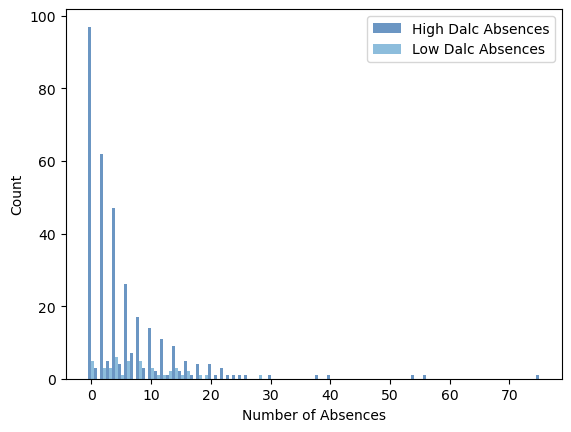

In [37]:
#Displaying the two groups on the same axis of a histogram 
#the total width of the two bars is 1.0, so 0.50 allows half of the space for each bar. 
width = 0.50
#thinkplot.preplot takes the number of histograms we are plotting and chooses colors for each plot. 
thinkplot.PrePlot(2)
#Setting HighDalcAb as the right bar & LowDalcAb to the left bar
thinkplot.Hist(HighDalcAb_Hist, align='right', width=width)
thinkplot.Hist(LowDalcAb_Hist, align='left', width=width)
#Configuring the histogram & labeling the x and y labels of the graph
thinkplot.Config(xlabel='Number of Absences', ylabel='Count')
#I am creating a histogram first, for me to use as a comparison to the PMF produced below...

The histogram above is useful because it makes the most frequent values for each group instantly perceptable. By plotting a Probability Mass Function (PMF) instead of a histogram, we are able to compare the two distributions without the differences in sample size between the two groups misleading our analysis. 

A PMF is another way to represent the distribution by mapping each value to its probability. Computing the PMF's below utilize the HighDalc and Low Dalc variables that were created to separate the two groups to compare their absences. 
* Student absences are a great variable to use for creating a PMF because they are a discrete variable. 

In [38]:
#Computing PMFs for the two groups and setting the legend for each PMF
HighDalcAb_pmf = thinkstats2.Pmf(HighDalc.absences, label="High Dalc Absences")
LowDalcAb_pmf = thinkstats2.Pmf(LowDalc.absences, label="Low Dalc Absences")

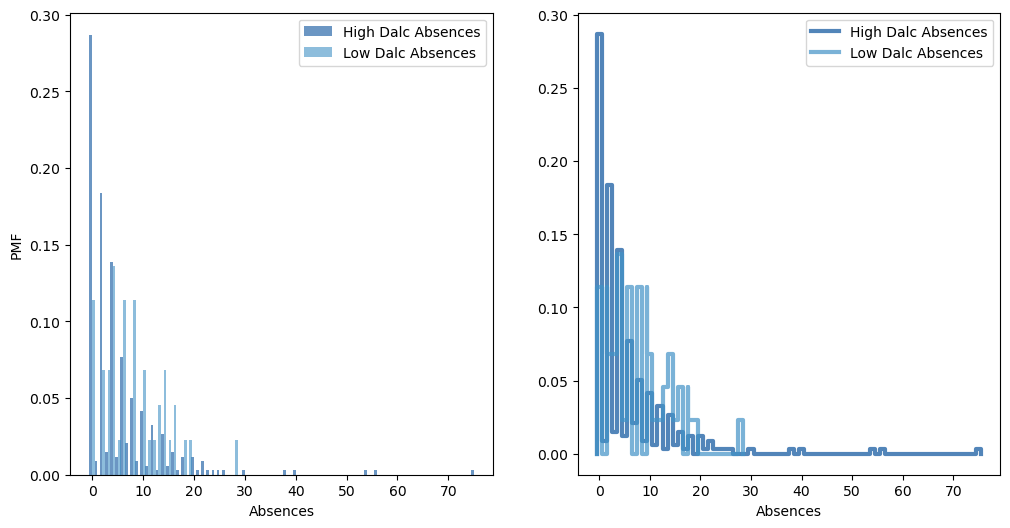

In [39]:
#Displaying two groups on the same axis of a PMF
#the total width of the two bars is 1.0, so 0.50 allows half of the space for each bar. 
width = 0.55
#the two parameters for thinkplot.preplot makes a grid of figures, in this case one row of two figures. 
thinkplot.PrePlot(2, cols=2)
#Configures the PMFs for the two groups as the figure on the left with thinkplot.hist
thinkplot.Hist(HighDalcAb_pmf, align="right", width=width)
thinkplot.Hist(LowDalcAb_pmf, align="left", width=width)
thinkplot.Config(xlabel="Absences", ylabel="PMF")

#reset the color generator
thinkplot.PrePlot(2)
#switch to a second figure
thinkplot.SubPlot(2)
#Configures the PMFs for the two groups as the figure on the right with thinkplot.Pmfs
thinkplot.Pmfs([HighDalcAb_pmf, LowDalcAb_pmf])
thinkplot.Config(xlabel="Absences")

### Comparison
My expectation was that students with a higher weekday (Dalc) alcohol consumption would have a higher probability to accumulate more absences than students with a lower weekday alcohol consumtion.

**Results**
* It is immediately apparent that students in the higher weekday (Dalc) alcohol consumption are representative of all of absences days 30-70+ 

... Lets create new PMF's that zoom in on the 0-40 absences values to get a better look at what's occuring between the two groups...

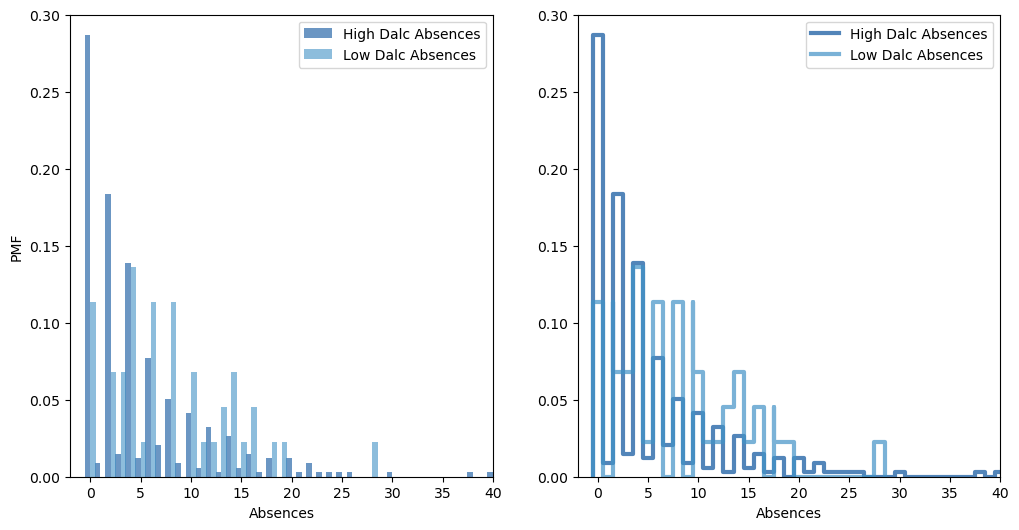

In [40]:
#Displaying two groups on the same axis of a PMF
width = 0.55
#Setting x-axis values to include absences from -5 (for spacing) to 40 absences, and y-axis values 0-0.30 (to match the PMF above). 
axis = [-2, 40, 0, 0.3]
thinkplot.PrePlot(2, cols=2)
thinkplot.Hist(HighDalcAb_pmf, align="right", width=width)
thinkplot.Hist(LowDalcAb_pmf, align="left", width=width)
thinkplot.Config(xlabel="Absences", ylabel="PMF", axis=axis)

thinkplot.PrePlot(2)
thinkplot.SubPlot(2)
thinkplot.Pmfs([HighDalcAb_pmf, LowDalcAb_pmf])
thinkplot.Config(xlabel="Absences", axis=axis)

**Results**
* We can see the bars of our two groups significantly better in these two PMFs
* In the 6-20 absences range, the lower weekday (Dalc) alcohol consumption group actually displays a higher probability of absences compared to sudents with a higher alcohol consumption. This was not my expectation when I formulated my statistical question. 

## CDF of Absences
The Cumulative Distribution Function (CDF) maps from values to their percentile rank. A CDF evaluates for a particular value of x, the fraction of valued in the distribution that are less than or equal to x. 

Below we will evaluate a CDF of the variable **absences** 

In [41]:
#Defining the CDF function that takes a sequence (t) and a value of (x).  
def EvalCdf(sample, x):
    count = 0.0
    for value in sample:
        if value <= x:
            count += 1

    prob = count / len(sample)
    return prob

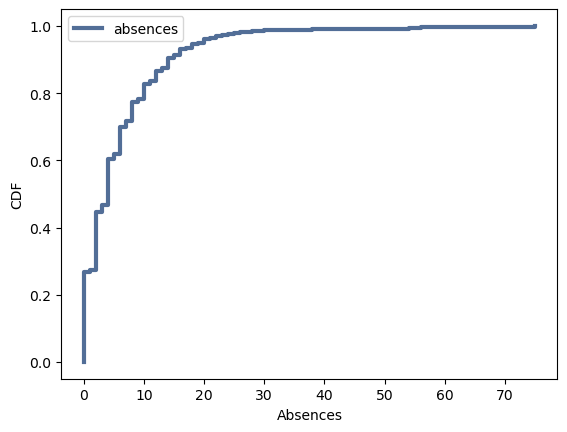

In [42]:
cdf = thinkstats2.Cdf(dfStud.absences, label='absences')
thinkplot.Cdf(cdf)
thinkplot.Config(xlabel='Absences', ylabel='CDF', loc='upper left')

In [43]:
#cdf.Prob evaluates the CDF by computing the fraction of values less than or equal to the given value. 
#Our incline stops around 20, so let's see what percentage of absences are <=20 days. 
cdf.Prob(20)

0.9607329842931938

In [44]:
#Our sharpest incline occurs from 0-10, so let's see what percentage of absences are <=10 days. 
cdf.Prob(10)

0.8272251308900523

In [45]:
#cdf.Value evaluates the inverse CDF. 
#Given a fraction (such as 0.5), it computes the corresponding value.  
#The median is the value that corresponds to 0.5.
cdf.Value(0.5)

4

### Absences CDF Evaluation
**What does this tell me about the variable Absences?**
* One way to interpret a CDF is to look at the percentiles.
  * 96% of the absences are less than or equal to 20 days.
  * 83% of absences are less than or equal to 10 days.
  * The median value of absences is 4 days. 
* The CDF provides a visualization of the shape of the distribution.
  * More common values appear as steep or vertical sections of the CDF.
  * The steepest incline is values for students with 0 absences. 
  * The incline remains steep from 0-20, then levels out to less common absences between 20-70+.
 
**How does this address my statistical question?**
  * The mean number of absences is 6 days, and the median is 4 days.
  * Over 80% of students having absences less than or equal to 10 days. 
  * This information gained from this CDF will help me address my statistical question by giving me an idea of the "normal" number of absences a student should be accruing throughout the year. As a comparison to the larger number of absences a student with a higher school day (Dalc) or weekend (Walc) level of alcohol consumption might have. 

## Analytical Distribution
Looking at the five variables chosen for this project, different analytical distributions could be used to best display each variable's data for analysis. For example...
* **Walc** and **Dalc**- Both of these distributions are asymmetric, right skewed. The analytic distribution I would use to display the data for these variables is a lognormal distribution. By applying a log function to the x-axis, this will take the skewed distribution and make it normal in order to create a better model/visualization of the data. 
* **absences**- This distribution is asymmetric, right skewed with a tail extending very far to the right. This distribution follows the 80/20 rule, where 80 percent of the absences come from 20 percent of the students. Therefore, I would use a pareto distribution to represent this data. 
* **Math** and **Reading**- Both of these distributions are normal with a bell-curve shape. The analytical distribution I would use to display the data for these variables is the normal distribution. 

Below you will see a normal distribution for the **Reading** variable:

Mean, Var 70.19148936170212 109.51652331371662
Sigma 10.46501425291512


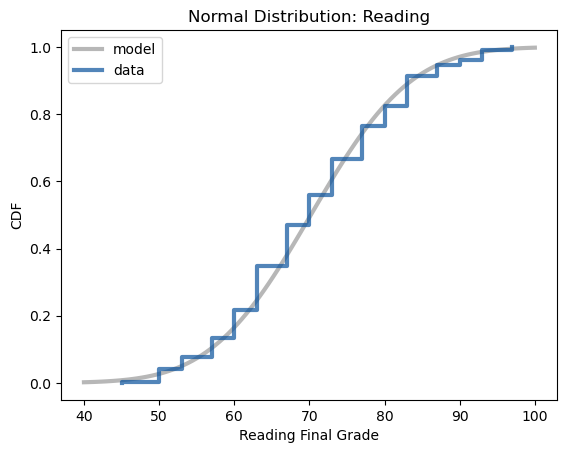

In [49]:
Reading = dfStud['Reading']
# estimate parameters: trimming outliers yields a better fit
mu, var = thinkstats2.TrimmedMeanVar(Reading, p=0.01)
print("Mean, Var", mu, var)

# plot the model
sigma = np.sqrt(var)
print("Sigma", sigma)
#Reading grades range from 45 to 97, so I set the high and low for the model slightly above and below the min and max values. 
xs, ps = thinkstats2.RenderNormalCdf(mu, sigma, low=40, high=100)

thinkplot.Plot(xs, ps, label="model", color="0.6")

# plot the data
cdf = thinkstats2.Cdf(Reading, label="data")

thinkplot.PrePlot(1)
thinkplot.Cdf(cdf)
thinkplot.Config(title="Normal Distribution: Reading", xlabel="Reading Final Grade", ylabel="CDF")

### Analysis
**How does this analytical distribution apply to this data set?**

# Project Summary 
The statistical question I formulated for this data was: Is there a correlation between secondary school age student alcohol consumption and student absenteeism or poor academic performance? 
